In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras 
from keras import Sequential
from keras.layers import Dense, Conv2D , MaxPooling2D,Flatten,BatchNormalization,Dropout,GlobalAveragePooling2D

In [70]:
# generators - divides data into batches and ram loads some amount of data at a time 

In [71]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=r"C:\files\programming\Python\deep_learning\datasets\large\dogs_vs_cats\train",
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=r"C:\files\programming\Python\deep_learning\datasets\large\dogs_vs_cats\train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [72]:
# normalize 
def process(image,label):
    image = tf.cast(image/255. , tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [73]:
# creating cnn model
# 3 cn filters 32->64->128

model = Sequential()

# cn layer 1
model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

# cn layer 2
model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

# cn layer 3
model.add(Conv2D(128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

# flatten layer
# model.add(Flatten())
model.add(GlobalAveragePooling2D())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))

In [74]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 256, 256, 32)      896       
                                                                 
 batch_normalization_6 (Batc  (None, 256, 256, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 128, 128, 32)     0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 128, 128, 64)      18496     
                                                                 
 batch_normalization_7 (Batc  (None, 128, 128, 64)     256       
 hNormalization)                                                 
                                                      

In [75]:
model.compile(optimizer='adam',loss = 'binary_crossentropy',metrics=['Accuracy'])

In [76]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [77]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds,callbacks=[early_stop])

Epoch 1/10
625/625 [==============================] - 68s 106ms/step - loss: 0.6453 - Accuracy: 0.6199 - val_loss: 0.6375 - val_Accuracy: 0.6228
Epoch 2/10
625/625 [==============================] - 65s 105ms/step - loss: 0.5964 - Accuracy: 0.6781 - val_loss: 0.6014 - val_Accuracy: 0.6774
Epoch 3/10
625/625 [==============================] - 66s 105ms/step - loss: 0.5548 - Accuracy: 0.7164 - val_loss: 0.5898 - val_Accuracy: 0.6818
Epoch 4/10
625/625 [==============================] - 66s 106ms/step - loss: 0.5291 - Accuracy: 0.7383 - val_loss: 0.5661 - val_Accuracy: 0.7060
Epoch 5/10
625/625 [==============================] - 67s 107ms/step - loss: 0.4882 - Accuracy: 0.7673 - val_loss: 0.8892 - val_Accuracy: 0.5958
Epoch 6/10
625/625 [==============================] - 66s 105ms/step - loss: 0.4539 - Accuracy: 0.7896 - val_loss: 0.4480 - val_Accuracy: 0.8020
Epoch 7/10
625/625 [==============================] - 66s 106ms/step - loss: 0.4040 - Accuracy: 0.8186 - val_loss: 0.4137 - val_Ac

In [78]:

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [79]:
print(history.history.keys())

dict_keys(['loss', 'Accuracy', 'val_loss', 'val_Accuracy'])


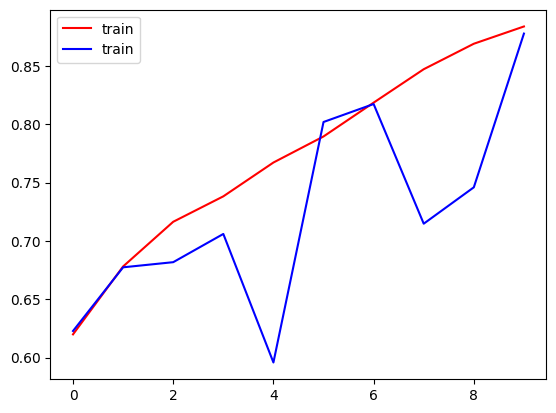

In [80]:
import matplotlib.pyplot as plt 
plt.plot(history.history['Accuracy'],color='red',label='train')
plt.plot(history.history['val_Accuracy'],color='blue',label='train')
plt.legend()
plt.show()

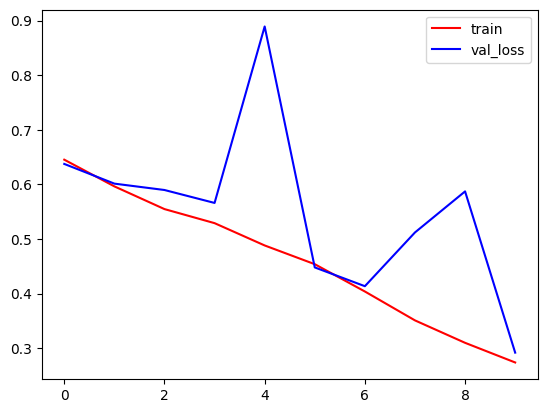

In [81]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='val_loss')
plt.legend()
plt.show()

In [82]:

# overfitting

In [83]:
# # ways to reduce overfitting->
# add more data 
# data augmentation->creating more data with existing
# l1/l2 regression
# dropout
# batch normalization
# reduce complexity

In [84]:
import cv2

In [97]:
test_img=cv2.imread('datasets/large/dogs_vs_cats/test_img/dog2.jpg')

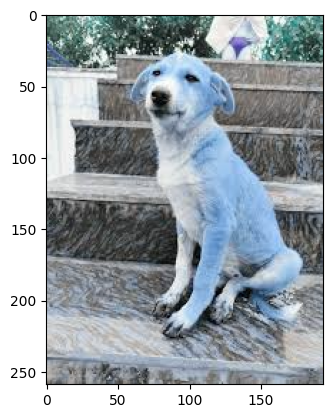

In [98]:
plt.imshow(test_img)

In [99]:
test_img.shape

(259, 194, 3)

In [100]:
test_img=cv2.resize(test_img,(256,256))

In [101]:
test_input = test_img.reshape((1,256,256,3))
# converted into a  4 d tensor as batch

In [102]:
model.predict(test_input)

1/1 [==============================] - 0s 16ms/step


array([[1.]], dtype=float32)

In [103]:
model.save("cat_dog_classifier.keras")

In [105]:
from tensorflow.keras.models import load_model

loaded_model = load_model("cat_dog_classifier.keras")
loaded_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 256, 256, 32)      896       
                                                                 
 batch_normalization_6 (Batc  (None, 256, 256, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 128, 128, 32)     0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 128, 128, 64)      18496     
                                                                 
 batch_normalization_7 (Batc  (None, 128, 128, 64)     256       
 hNormalization)                                                 
                                                      

In [106]:
model.save_weights("cat_dog_weights.weights.h5")

In [ ]:
# way to automatically save the best validation model during training
# from tensorflow.keras.callbacks import ModelCheckpoint

# checkpoint = ModelCheckpoint(
#     "best_cat_dog_model.keras",
#     monitor="val_accuracy",
#     save_best_only=True,
#     verbose=1
# )

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=20,
#     callbacks=[checkpoint]
# )